In [57]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
import pandera as pa
import warnings
import os

In [58]:
warnings.filterwarnings('ignore')

In [59]:
DATA_PATH     = "Dataset for Data Analytics.xlsx"
TARGET_COLUMN = "OrderStatus"  # Identified as target
Correlation_Threshold = 0.80
Missing_Lower    = 0.05
Missing_Higher   = 0.20

In [60]:
print("=" * 60)
print("LOADING DATASET & EDA")
print("=" * 60)

LOADING DATASET & EDA


In [61]:
df = pd.read_excel(DATA_PATH)

In [62]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column data types:")
print(df.dtypes)

Dataset shape: 1200 rows x 14 columns

Column data types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [63]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [64]:
#Statistical Analysis
df.describe(include='all')

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD200000,NaN,C38840,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK37947903,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000


In [65]:
missing_count = df.isnull().sum()
missing_percentage   = df.isnull().mean() * 100
missing_df    = pd.DataFrame({
    'Missing Count': missing_count,
    '%':     missing_percentage.round(2)
}).sort_values('%', ascending=False)

In [66]:
print("Missing Values Per Column:")
missing_df[missing_df['Missing Count'] > 0]

Missing Values Per Column:


,Missing Count,%
CouponCode,309,25.75


In [67]:
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [68]:
if TARGET_COLUMN in numeric_cols:
    numeric_cols.remove(TARGET_COLUMN)
if TARGET_COLUMN in categorical_cols:
    categorical_cols.remove(TARGET_COLUMN)

In [69]:
print(f"Numeric columns    : {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"Target column      : {TARGET_COLUMN}")

Numeric columns    : ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
Categorical columns: ['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'TrackingNumber', 'CouponCode', 'ReferralSource']
Target column      : OrderStatus


In [70]:
print("\n" + "=" * 60)
print("EDA VISUALIZATIONS")
print("=" * 60)


EDA VISUALIZATIONS


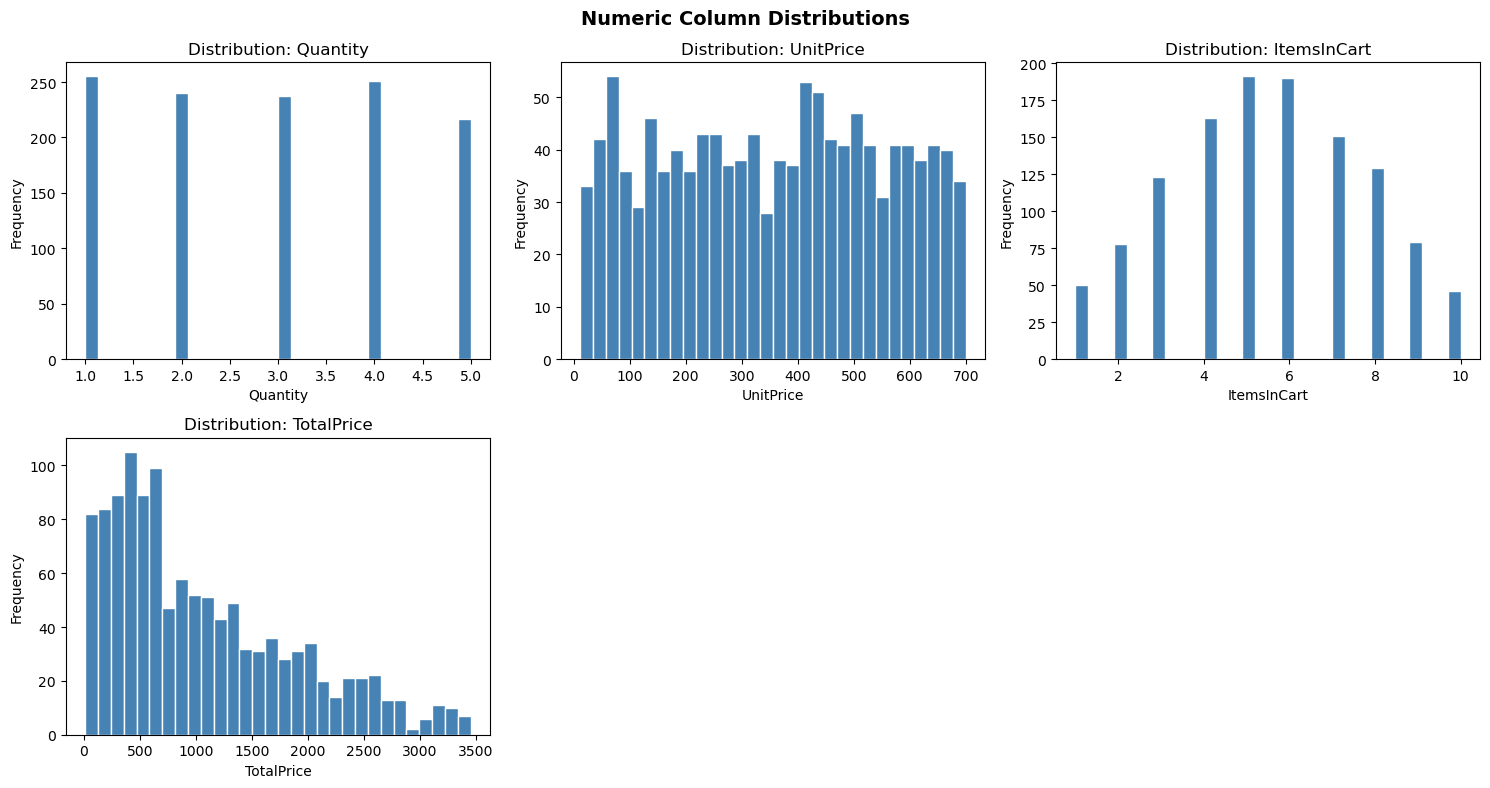

[SAVED] eda_distributions.png


In [71]:
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
        axes[i].set_title(f'Distribution: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Numeric Column Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[SAVED] eda_distributions.png")

[SAVED] eda_correlation_heatmap.png


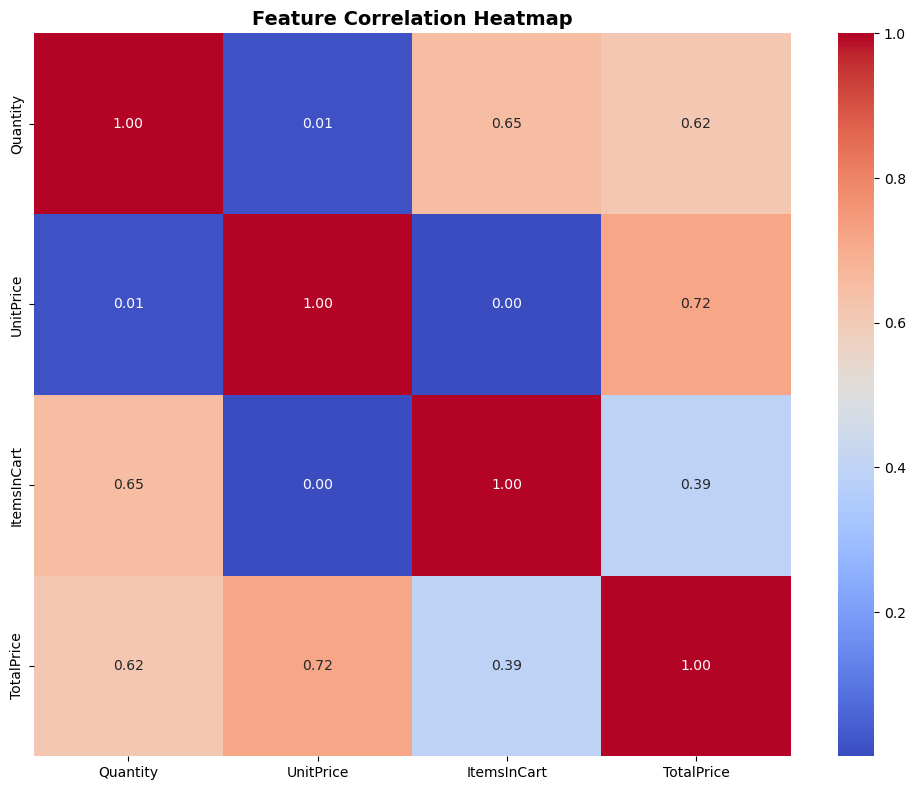

In [72]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    print("[SAVED] eda_correlation_heatmap.png")

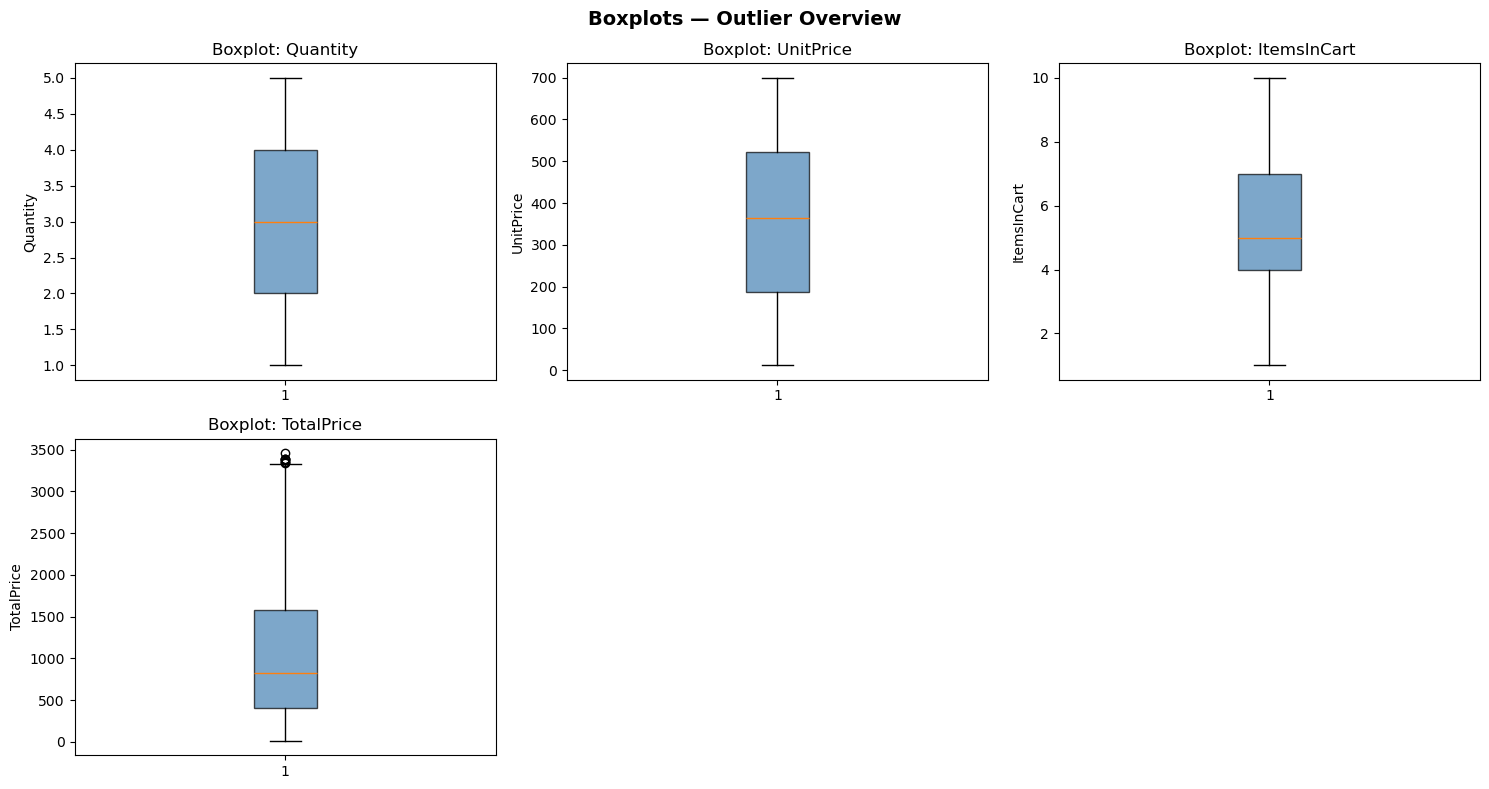

[SAVED] eda_boxplots.png


In [73]:
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(numeric_cols):
        axes[i].boxplot(df[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='steelblue', alpha=0.7))
        axes[i].set_title(f'Boxplot: {col}')
        axes[i].set_ylabel(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplots — Outlier Overview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[SAVED] eda_boxplots.png")

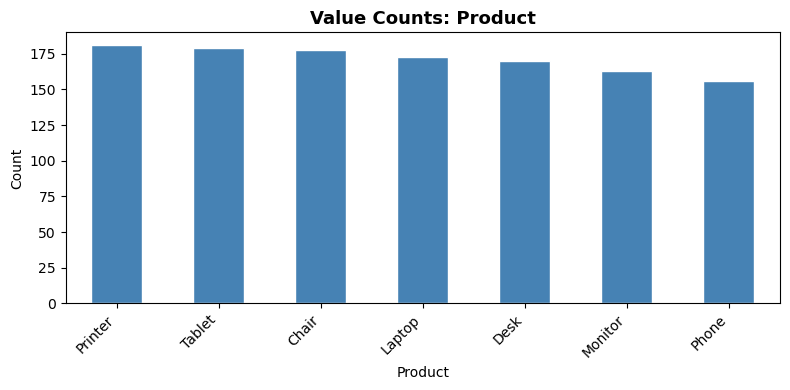

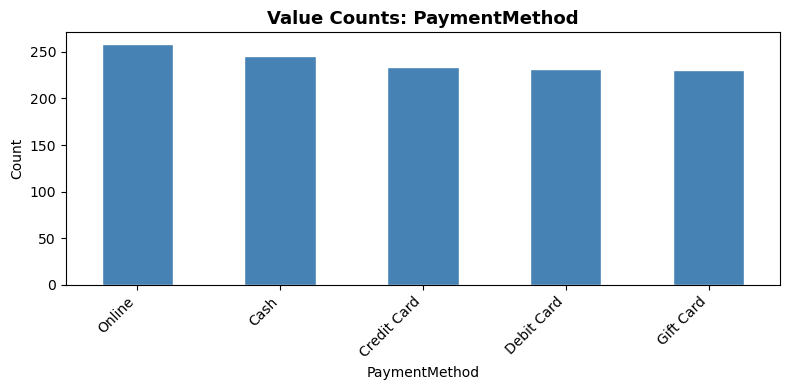

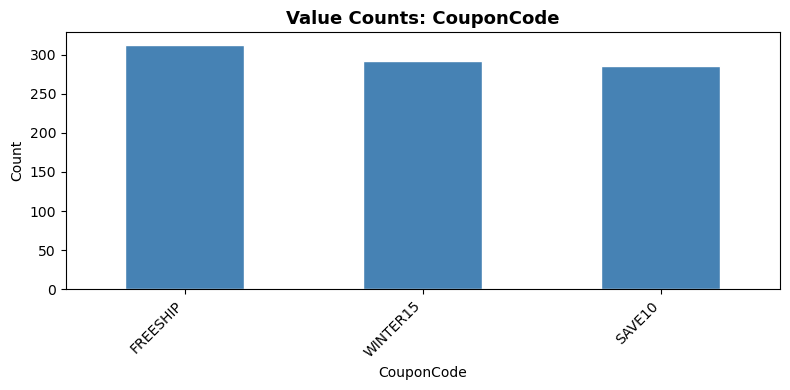

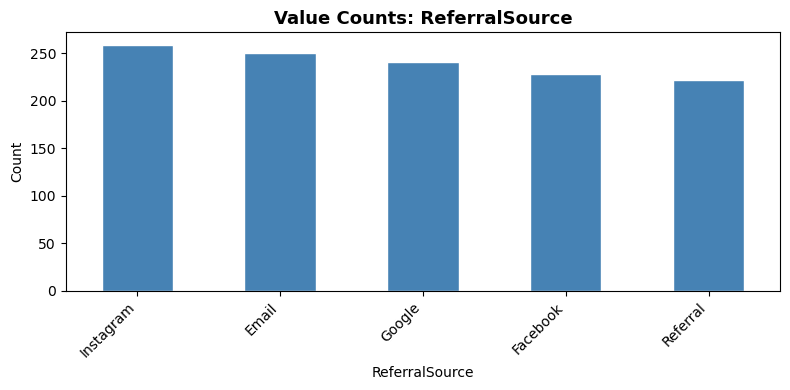

[SAVED] categorical bar charts


In [74]:
if categorical_cols:
    #Filters out high-cardinality columns first
    valid_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    for col in valid_cols[:4]:
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
        plt.title(f'Value Counts: {col}', fontsize=13, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'eda_categorical_{col}.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    print("[SAVED] categorical bar charts")

In [75]:
print("\n" + "=" * 60)
print("HANDLING MISSING VALUES")
print("=" * 60)


HANDLING MISSING VALUES


In [76]:
df_clean = df.copy()

In [77]:
for col in df_clean.columns:
    if col == TARGET_COLUMN:
        continue

    pct = df_clean[col].isnull().mean()
    if pct == 0:
        continue

    col_type = df_clean[col].dtype

    # < 5% → Drop rows
    if pct < Missing_Lower:
        before = len(df_clean)
        df_clean.dropna(subset=[col], inplace=True)
        print(f"[DROP]   '{col}' ({pct*100:.1f}% missing) → dropped {before - len(df_clean)} rows")

    # 5% – 20% → Statistical imputation
    elif pct <= Missing_Higher:
        if col_type in [np.float64, np.int64, float, int]:
            skewness = df_clean[col].skew()
            if abs(skewness) > 1:
                fill_val = df_clean[col].median()
                df_clean[col].fillna(fill_val, inplace=True)
                print(f"[MEDIAN] '{col}' ({pct*100:.1f}% missing, skew={skewness:.2f}) → filled with median={fill_val:.4f}")
            else:
                fill_val = df_clean[col].mean()
                df_clean[col].fillna(fill_val, inplace=True)
                print(f"[MEAN]   '{col}' ({pct*100:.1f}% missing, skew={skewness:.2f}) → filled with mean={fill_val:.4f}")
        else:
            fill_val = df_clean[col].mode()[0]
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"[MODE]   '{col}' ({pct*100:.1f}% missing) → filled with mode='{fill_val}'")

    # > 20% → KNN imputation
    else:
        print(f"[KNN]    '{col}' ({pct*100:.1f}% missing) → will use KNN imputation")

[KNN]    'CouponCode' (25.8% missing) → will use KNN imputation


In [78]:
#KNN Imputation for columns > 20% missing
high_missing_cols = [
    col for col in df_clean.columns
    if col != TARGET_COLUMN
    and df_clean[col].isnull().mean() > Missing_Higher
    and df_clean[col].dtype in [np.float64, np.int64, float, int]
]

In [79]:
if high_missing_cols:
    print(f"\n[KNN] Running KNN imputation on: {high_missing_cols}")
    imputer = KNNImputer(n_neighbors=5)
    df_clean[high_missing_cols] = imputer.fit_transform(df_clean[high_missing_cols])
    print("[KNN] Done.")

In [80]:
#Group-wise conditional imputation
GROUP_COL  = 'PaymentMethod'   # e.g. 'city', 'department'
TARGET_IMP = 'UnitPrice'    # column to impute
df_clean[TARGET_IMP] = df_clean.groupby(GROUP_COL)[TARGET_IMP].transform(lambda x: x.fillna(x.median()))

In [81]:
print(f"Missing values after imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("[OK] No missing values remain." if df_clean.isnull().sum().sum() == 0 else "")

Missing values after imputation:
CouponCode    309
dtype: int64



In [82]:
print("\n" + "=" * 60)
print("OUTLIER DETECTION & NEUTRALIZATION")
print("=" * 60)


OUTLIER DETECTION & NEUTRALIZATION


In [83]:
outlier_report = []

for col in numeric_cols:
    if col not in df_clean.columns:
        continue

    #IQR
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    iqr_outliers = ((df_clean[col] < lower_iqr) | (df_clean[col] > upper_iqr)).sum()

    #Z-Score
    z_scores      = np.abs(stats.zscore(df_clean[col].dropna()))
    zscore_outliers = (z_scores > 3).sum()

    #Winsorization: cap at IQR boundaries (preserves row count)
    df_clean[col] = np.clip(df_clean[col], lower_iqr, upper_iqr)

    outlier_report.append({
        'Column':           col,
        'IQR Outliers':     iqr_outliers,
        'Z-Score Outliers': zscore_outliers,
        'Lower Bound':      round(lower_iqr, 4),
        'Upper Bound':      round(upper_iqr, 4),
        'Treatment':        'Winsorized (clipped)'
    })

    print(f"[OUTLIER] '{col}' → IQR outliers: {iqr_outliers} | "
          f"Z-score outliers: {zscore_outliers} | "
          f"Bounds: [{lower_iqr:.2f}, {upper_iqr:.2f}]")

[OUTLIER] 'Quantity' → IQR outliers: 0 | Z-score outliers: 0 | Bounds: [-1.00, 7.00]
[OUTLIER] 'UnitPrice' → IQR outliers: 0 | Z-score outliers: 0 | Bounds: [-317.20, 1024.83]
[OUTLIER] 'ItemsInCart' → IQR outliers: 0 | Z-score outliers: 0 | Bounds: [-0.50, 11.50]
[OUTLIER] 'TotalPrice' → IQR outliers: 8 | Z-score outliers: 0 | Bounds: [-1341.41, 3330.41]


In [84]:
outlier_df = pd.DataFrame(outlier_report)
print("Outlier Summary:")
print(outlier_df.to_string(index=False))

Outlier Summary:
     Column  IQR Outliers  Z-Score Outliers  Lower Bound  Upper Bound            Treatment
   Quantity             0                 0      -1.0000       7.0000 Winsorized (clipped)
  UnitPrice             0                 0    -317.1987    1024.8312 Winsorized (clipped)
ItemsInCart             0                 0      -0.5000      11.5000 Winsorized (clipped)
 TotalPrice             8                 0   -1341.4125    3330.4075 Winsorized (clipped)


In [85]:
print("\n" + "=" * 60)
print("ONE-HOT ENCODING")
print("=" * 60)


ONE-HOT ENCODING


In [86]:
if TARGET_COLUMN in df_clean.columns:
    target_series = df_clean[TARGET_COLUMN].copy()
    df_features   = df_clean.drop(columns=[TARGET_COLUMN])
else:
    df_features = df_clean.copy()

cat_cols_present = [c for c in categorical_cols if c in df_features.columns]

if cat_cols_present:
    before_cols = df_features.shape[1]
    df_features = pd.get_dummies(df_features, columns=cat_cols_present, drop_first=True)
    after_cols  = df_features.shape[1]
    print(f"Encoded {len(cat_cols_present)} columns: {cat_cols_present}")
    print(f"Columns before: {before_cols} → after: {after_cols}")
else:
    print("[OHE] No categorical columns to encode.")

# Reattach target
if TARGET_COLUMN in df_clean.columns:
    df_features[TARGET_COLUMN] = target_series.values

Encoded 8 columns: ['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'TrackingNumber', 'CouponCode', 'ReferralSource']
Columns before: 13 → after: 4261


In [87]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)


FEATURE ENGINEERING


In [88]:
num_cols_now = df_features.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COLUMN in num_cols_now:
    num_cols_now.remove(TARGET_COLUMN)

engineered = []

#Feature 1: Ratio of first two numeric columns
if len(num_cols_now) >= 2:
    col_a, col_b = num_cols_now[0], num_cols_now[1]
    feat_name = f'{col_a}_to_{col_b}_ratio'
    df_features[feat_name] = df_features[col_a] / (df_features[col_b].replace(0, np.nan))
    df_features[feat_name].fillna(0, inplace=True)
    engineered.append(feat_name)
    print(f"[FEAT 1] '{feat_name}' = {col_a} / {col_b}")

#Feature 2: Sum / aggregate of numeric columns
if len(num_cols_now) >= 2:
    feat_name = 'numeric_sum'
    df_features[feat_name] = df_features[num_cols_now[:3]].sum(axis=1)
    engineered.append(feat_name)
    print(f"[FEAT 2] '{feat_name}' = sum of first 3 numeric cols (vectorized)")

#Feature 3: Z-Score normalized version of first numeric col
if len(num_cols_now) >= 1:
    col_a     = num_cols_now[0]
    feat_name = f'{col_a}_zscore'
    df_features[feat_name] = (
        (df_features[col_a] - df_features[col_a].mean()) / df_features[col_a].std()
    )
    engineered.append(feat_name)
    print(f"[FEAT 3] '{feat_name}' = Z-score normalization of '{col_a}'")

#Feature 4: Binary high/low flag based on median
if len(num_cols_now) >= 1:
    col_a     = num_cols_now[0]
    feat_name = f'{col_a}_above_median'
    df_features[feat_name] = (df_features[col_a] > df_features[col_a].median()).astype(int)
    engineered.append(feat_name)
    print(f"[FEAT 4] '{feat_name}' = 1 if {col_a} > median, else 0")

#Feature 5: Interaction term (product of two columns)
if len(num_cols_now) >= 2:
    col_a, col_b = num_cols_now[0], num_cols_now[1]
    feat_name = f'{col_a}_x_{col_b}'
    df_features[feat_name] = df_features[col_a] * df_features[col_b]
    engineered.append(feat_name)
    print(f"[FEAT 5] '{feat_name}' = {col_a} * {col_b}")

print(f"{len(engineered)} new features engineered: {engineered}")

[FEAT 1] 'Quantity_to_UnitPrice_ratio' = Quantity / UnitPrice
[FEAT 2] 'numeric_sum' = sum of first 3 numeric cols (vectorized)
[FEAT 3] 'Quantity_zscore' = Z-score normalization of 'Quantity'
[FEAT 4] 'Quantity_above_median' = 1 if Quantity > median, else 0
[FEAT 5] 'Quantity_x_UnitPrice' = Quantity * UnitPrice
5 new features engineered: ['Quantity_to_UnitPrice_ratio', 'numeric_sum', 'Quantity_zscore', 'Quantity_above_median', 'Quantity_x_UnitPrice']


In [89]:
print("\n" + "=" * 60)
print("COLLINEARITY ERADICATION")
print("=" * 60)


COLLINEARITY ERADICATION


Found 5 collinear pair(s) above 0.8:
  → 'numeric_sum' & 'UnitPrice' | correlation = 0.9999
  → 'Quantity_zscore' & 'Quantity' | correlation = 1.0000
  → 'Quantity_above_median' & 'Quantity' | correlation = 0.8626
  → 'Quantity_above_median' & 'Quantity_zscore' | correlation = 0.8626
  → 'Quantity_x_UnitPrice' & 'TotalPrice' | correlation = 1.0000
  [DROP] 'numeric_sum' (corr with target=0.0093) → keep 'UnitPrice' (corr with target=0.0098)
  [DROP] 'Quantity' (corr with target=0.0521) → keep 'Quantity_zscore' (corr with target=0.0521)
  [DROP] 'Quantity_above_median' (corr with target=0.0476) → keep 'Quantity' (corr with target=0.0521)
  [DROP] 'Quantity_above_median' (corr with target=0.0476) → keep 'Quantity_zscore' (corr with target=0.0521)
  [DROP] 'TotalPrice' (corr with target=0.0321) → keep 'Quantity_x_UnitPrice' (corr with target=0.0323)

[OK] Dropped 4 collinear column(s): ['numeric_sum', 'Quantity', 'TotalPrice', 'Quantity_above_median']


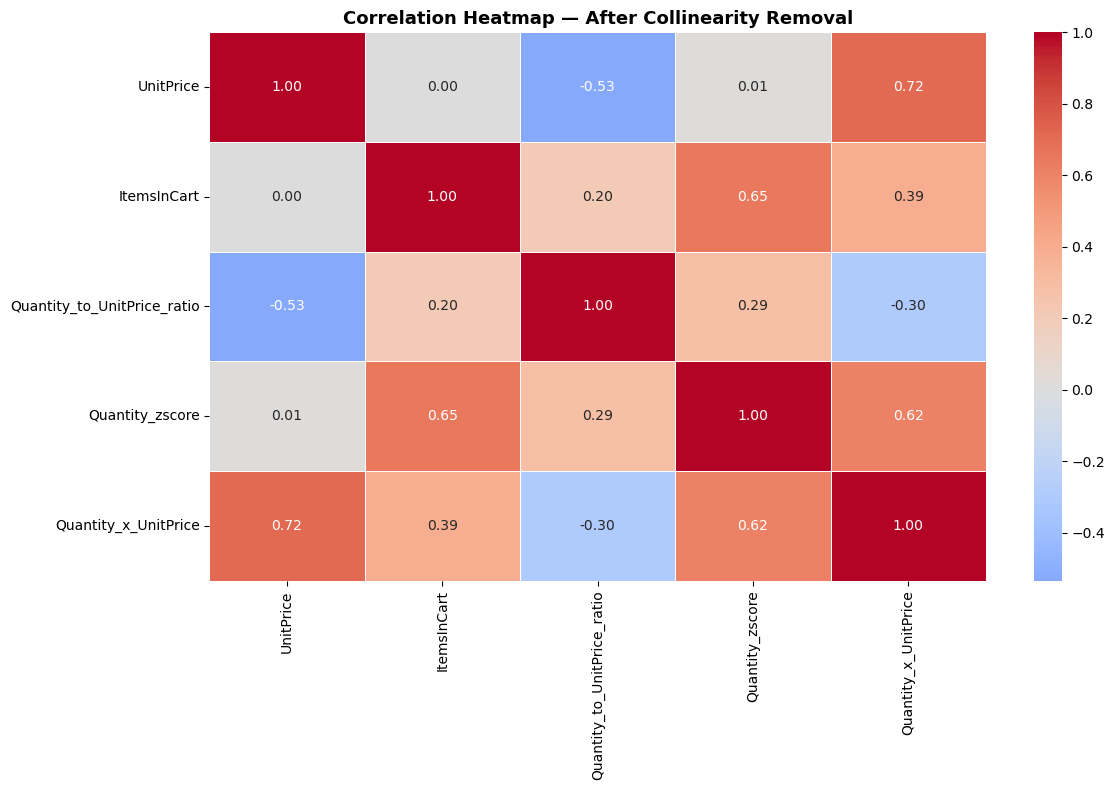

[SAVED] final_correlation_heatmap.png


In [90]:
num_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COLUMN in num_features:
    num_features.remove(TARGET_COLUMN)

#Absolute correlation matrix
corr_matrix = df_features[num_features].corr().abs()

#Upper triangle only (avoid duplicates)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

#Find collinear pairs above threshold
collinear_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > Correlation_Threshold
]

cols_to_drop = set()

if collinear_pairs:
    print(f"Found {len(collinear_pairs)} collinear pair(s) above {Correlation_Threshold}:")
    for col_a, col_b, corr_val in collinear_pairs:
        print(f"  → '{col_a}' & '{col_b}' | correlation = {corr_val:.4f}")

    #Keep the one MORE correlated with target
    if TARGET_COLUMN in df_features.columns:
        #convert target column to numeric if it contains strings (e.g., 'Shipped')
        if not pd.api.types.is_numeric_dtype(df_features[TARGET_COLUMN]):
            #Create a temporary dataframe with target converted to numeric codes
            temp_df = df_features[num_features].copy()
            temp_df[TARGET_COLUMN] = df_features[TARGET_COLUMN].astype('category').cat.codes
            target_corr = temp_df.corr()[TARGET_COLUMN].abs()
        else:
            target_corr = df_features[num_features + [TARGET_COLUMN]].corr()[TARGET_COLUMN].abs()

        for col_a, col_b, _ in collinear_pairs:
            corr_a = target_corr.get(col_a, 0)
            corr_b = target_corr.get(col_b, 0)
            drop   = col_b if corr_a >= corr_b else col_a
            keep   = col_a if drop == col_b else col_b
            cols_to_drop.add(drop)
            print(f"  [DROP] '{drop}' (corr with target={target_corr.get(drop,0):.4f}) "
                  f"→ keep '{keep}' (corr with target={target_corr.get(keep,0):.4f})")
    else:
        # No target column — drop based on position
        for col_a, col_b, _ in collinear_pairs:
            cols_to_drop.add(col_b)
            print(f"  [DROP] '{col_b}' (no target column — dropping second in pair)")

    df_features.drop(columns=list(cols_to_drop), inplace=True)
    print(f"\n[OK] Dropped {len(cols_to_drop)} collinear column(s): {list(cols_to_drop)}")
else:
    print(f"[OK] No collinear pairs found above threshold {Correlation_Threshold}. Nothing dropped.")

#Final correlation heatmap after cleaning
final_num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
if len(final_num_cols) > 1:
    plt.figure(figsize=(12, 8))
    final_corr = df_features[final_num_cols].corr()
    sns.heatmap(final_corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5)
    plt.title('Correlation Heatmap — After Collinearity Removal', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('final_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[SAVED] final_correlation_heatmap.png")

In [91]:
print("\n" + "=" * 60)
print("PANDERA SCHEMA VALIDATION")
print("=" * 60)


PANDERA SCHEMA VALIDATION


In [92]:
# Build schema dynamically from the cleaned dataframe
schema_cols = {}

for col in df_features.columns:
    dtype = df_features[col].dtype
    if dtype in [np.float64, float]:
        schema_cols[col] = pa.Column(float, nullable=False)
    elif dtype in [np.int64, np.int32, int]:
        schema_cols[col] = pa.Column(int, nullable=False)
    elif dtype == bool or (df_features[col].nunique() == 2
                           and set(df_features[col].unique()).issubset({0, 1})):
        schema_cols[col] = pa.Column(int, pa.Check.isin([0, 1]), nullable=False)
    else:
        schema_cols[col] = pa.Column(str, nullable=True)

schema = pa.DataFrameSchema(schema_cols, coerce=True)

try:
    validated_df = schema.validate(df_features, lazy=True)
    print("[OK] Pandera validation passed. All columns match expected schema.")
except pa.errors.SchemaErrors as e:
    print("[WARNING] Pandera found schema violations:")
    print(e.failure_cases)
    validated_df = df_features.copy()

[OK] Pandera validation passed. All columns match expected schema.


In [93]:
print("\n" + "=" * 60)
print("EXPORTING CLEAN DATASET")
print("=" * 60)


EXPORTING CLEAN DATASET


In [94]:
validated_df.to_excel("clean_dataset.xlsx", index=False)
print("[SAVED] clean_dataset.xlsx")

[SAVED] clean_dataset.xlsx


In [95]:
print("\n" + "=" * 60)
print("FINAL PIPELINE REPORT")
print("=" * 60)


FINAL PIPELINE REPORT


In [96]:
print(f"  Original dataset shape  : {df.shape}")
print(f"  Clean dataset shape     : {validated_df.shape}")
print(f"  Rows removed            : {df.shape[0] - validated_df.shape[0]}")
print(f"  Features added          : {len(engineered)} new engineered features")
print(f"  Columns dropped (collin): {len(cols_to_drop)}")
print(f"  Missing values remaining: {validated_df.isnull().sum().sum()}")
print(f"  Output files            : clean_dataset.csv")
print("=" * 60)
print("Pipeline complete. Your dataset is ML-ready.")

  Original dataset shape  : (1200, 14)
  Clean dataset shape     : (1200, 4263)
  Rows removed            : 0
  Features added          : 5 new engineered features
  Columns dropped (collin): 4
  Missing values remaining: 0
  Output files            : clean_dataset.csv
Pipeline complete. Your dataset is ML-ready.
